In [ ]:
# Resolve Data Inconsistencies
# Removed duplicate records and verified data uniqueness.
# Converted key financial variables to numeric formats and standardized inconsistent categorical labels.
# Transformed day-based variables into meaningful year-based features (e.g., age, employment years).
# Created informative indicator and summary features (e.g., job status, car ownership, contact score).
# Simplified high-cardinality categories (e.g., organization type) to reduce noise and improve model readiness.


In [2]:
import numpy as np
import pandas as pd
import random
np.random.seed(42)
random.seed(42)

df=pd.read_csv("/Users/elina/Downloads/home-credit-default-risk/application_train.csv")
df.head(5) # test
print(df.iloc[:, :41].isna().sum())
# Check duplicate rows
initial_shape=df.shape
df=df.drop_duplicates()
if initial_shape[0] - df.shape[0]==0:
    print("No duplicate rows were found.")
else:
    print(f"Removed {initial_shape[0] - df.shape[0]} duplicate rows. New shape: {df.shape}")

# Check Missing Values first 40 columns
df.iloc[:,:42].isna().sum()

# Fit data formats for AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AND AMOUNT_GOODS_PRICE
cols=["AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE"]
for c in cols:
    df[c]=pd.to_numeric(df[c],errors="coerce")
# Standardize categorical labels —> NAME_TYPE_SUITE
df["NAME_TYPE_SUITE"].unique()
df["NAME_TYPE_SUITE"].value_counts(dropna=False)
df["NAME_TYPE_SUITE"] = df["NAME_TYPE_SUITE"].replace(["Other_A", "Other_B", "Group of people"],"Other")

#Standardize categorical labels —> NAME_INCOME_TYPE
df["NAME_INCOME_TYPE"].value_counts(dropna=False)
#Standardize categorical labels —> NAME_EDUCATION_TYPE
df["NAME_EDUCATION_TYPE"].value_counts(dropna=False)
df["NAME_EDUCATION_TYPE"] = df["NAME_EDUCATION_TYPE"].replace(
    {
        "Academic degree": "Higher education",
        "Lower secondary": "Secondary / secondary special"
    }
)
# Convert DAYS_BIRTH to age
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)
# Drop original column
df.drop(columns=["DAYS_BIRTH"], inplace=True)
# Replace special value with NaN
df["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)
# Convert to years
df["EMPLOYED_YEARS"] = -df["DAYS_EMPLOYED"] / 365
# Employment indicator
df["HAS_JOB"] = df["DAYS_EMPLOYED"].notna().astype(int)
# Drop original column
df.drop(columns=["DAYS_EMPLOYED"], inplace=True)

#converts DAYS_REGISTRATION into years, bins it into meaningful residence-duration categories
df["REGISTRATION_YEARS"] = -df["DAYS_REGISTRATION"] / 365
df["REGISTRATION_YEARS_BIN"] = pd.cut(
    df["REGISTRATION_YEARS"],
    bins=[0, 1, 3, 5, 10, 20, 50],
    labels=["<1y", "1–3y", "3–5y", "5–10y", "10–20y", "20y+"]
)
df.drop(columns=["DAYS_REGISTRATION"], inplace=True)

df["ID_PUBLISH_YEARS"] = -df["DAYS_ID_PUBLISH"] / 365
df.drop(columns=["ID_PUBLISH_YEARS"], inplace=True)

df["HAS_CAR"] = df["OWN_CAR_AGE"].notna().astype(int)
df["OWN_CAR_AGE"] = df["OWN_CAR_AGE"].fillna(0)

#create a single feature that summarizes how many contact methods are available for each customer.
contact_cols = [
    "FLAG_MOBIL",
    "FLAG_EMP_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_CONT_MOBILE",
    "FLAG_PHONE",
    "FLAG_EMAIL"
]
df["CONTACT_SCORE"] = df[contact_cols].sum(axis=1)
df.drop(
    columns=[ "FLAG_MOBIL",
    "FLAG_EMP_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_CONT_MOBILE",
    "FLAG_PHONE",
    "FLAG_EMAIL"],
    inplace=True
)
print(df["CONTACT_SCORE"].head(5))

#Check OCCUPATION_TYPE
df["OCCUPATION_TYPE"].value_counts(dropna=False)
df["OCCUPATION_TYPE"].isna().sum()
df["OCCUPATION_TYPE"].isna().mean()

#Check Organization Type
df["ORGANIZATION_TYPE"].value_counts(dropna=False)
df["ORGANIZATION_TYPE"] = df["ORGANIZATION_TYPE"].replace("XNA", np.nan)
def simplify_org(x):
    if pd.isna(x):
        return np.nan
    if x.startswith("Business Entity"):
        return "Business"
    if x.startswith("Trade"):
        return "Trade"
    if x.startswith("Industry"):
        return "Industry"
    if x.startswith("Transport"):
        return "Transport"
    if x in ["Government", "Police", "Military", "Security Ministries"]:
        return "Public Sector"
    if x in ["School", "Kindergarten", "University"]:
        return "Education"
    if x in ["Bank", "Insurance", "Telecom"]:
        return "Finance/Telecom"
    if x == "Medicine":
        return "Healthcare"
    else:
        return x

df["ORG_TYPE_CLEAN"] = df["ORGANIZATION_TYPE"].apply(simplify_org)
freq = df["ORG_TYPE_CLEAN"].value_counts(normalize=True)
rare = freq[freq < 0.005].index

df["ORG_TYPE_CLEAN"] = df["ORG_TYPE_CLEAN"].replace(rare, "Other")

df.head(5)

SK_ID_CURR                          0
TARGET                              0
NAME_CONTRACT_TYPE                  0
CODE_GENDER                         0
FLAG_OWN_CAR                        0
FLAG_OWN_REALTY                     0
CNT_CHILDREN                        0
AMT_INCOME_TOTAL                    0
AMT_CREDIT                          0
AMT_ANNUITY                        12
AMT_GOODS_PRICE                   278
NAME_TYPE_SUITE                  1292
NAME_INCOME_TYPE                    0
NAME_EDUCATION_TYPE                 0
NAME_FAMILY_STATUS                  0
NAME_HOUSING_TYPE                   0
REGION_POPULATION_RELATIVE          0
DAYS_BIRTH                          0
DAYS_EMPLOYED                       0
DAYS_REGISTRATION                   0
DAYS_ID_PUBLISH                     0
OWN_CAR_AGE                    202929
FLAG_MOBIL                          0
FLAG_EMP_PHONE                      0
FLAG_WORK_PHONE                     0
FLAG_CONT_MOBILE                    0
FLAG_PHONE  

/var/folders/y0/clfwbm7x729d_5b50phhndcw0000gn/T/ipykernel_40490/2341789637.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)
/var/folders/y0/clfwbm7x729d_5b50phhndcw0000gn/T/ipykernel_40490/2341789637.py:45: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object,

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,EMPLOYED_YEARS,HAS_JOB,REGISTRATION_YEARS,REGISTRATION_YEARS_BIN,HAS_CAR,CONTACT_SCORE,ORG_TYPE_CLEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,1.0,25,1.745205,1,9.994521,5–10y,0,4,Business
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,45,3.254795,1,3.249315,3–5y,0,4,Education
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,52,0.616438,1,11.671233,10–20y,1,5,Public Sector
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,52,8.326027,1,26.939726,20y+,0,3,Business
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,54,8.323288,1,11.810959,10–20y,0,3,Other


In [7]:
# Exploratory Data Analysis (EDA)
# We now explore the dataset by:

# Viewing summary statistics.
# Plotting distributions of key numerical variables (to observe skewness).
# Examining the distribution of imbalanced categorical variables.
# Visualizing the correlation matrix to identify highly correlated features.

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
num_summary = (
    df.iloc[:, 1:33]
      .select_dtypes(include=["int64", "float64"])
      .describe()
)

print("Summary statistics for numerical columns (columns 2–41):")
print(num_summary)
cat_summary = (
    df.iloc[:, 1:41]
      .select_dtypes(include=["object", "category"])
      .describe()
)

print("Summary statistics for categorical columns (columns 2–41):")
print(cat_summary)


Summary statistics for numerical columns (columns 2–41):
              TARGET   CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT  \
count  307511.000000  307511.000000      3.075110e+05  3.075110e+05   
mean        0.080729       0.417052      1.687979e+05  5.990260e+05   
std         0.272419       0.722121      2.371231e+05  4.024908e+05   
min         0.000000       0.000000      2.565000e+04  4.500000e+04   
25%         0.000000       0.000000      1.125000e+05  2.700000e+05   
50%         0.000000       0.000000      1.471500e+05  5.135310e+05   
75%         0.000000       1.000000      2.025000e+05  8.086500e+05   
max         1.000000      19.000000      1.170000e+08  4.050000e+06   

         AMT_ANNUITY  AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  \
count  307511.000000     3.075110e+05               307511.000000   
mean    27108.572906     5.381527e+05                    0.020868   
std     14493.620956     3.694082e+05                    0.013831   
min      1615.500000     4.

/var/folders/y0/clfwbm7x729d_5b50phhndcw0000gn/T/ipykernel_40490/1039487832.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object", "category"])


Summary statistics for categorical columns (columns 2–41):
       NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
count              307511      307511       307511          307511   
unique                  2           3            2               2   
top            Cash loans           F            N               Y   
freq               278232      202448       202924          213312   

       NAME_TYPE_SUITE NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
count           306219           307511                         307511   
unique               5                8                              3   
top      Unaccompanied          Working  Secondary / secondary special   
freq            248526           158774                         222207   

       NAME_FAMILY_STATUS  NAME_HOUSING_TYPE OCCUPATION_TYPE  \
count              307511             307511          211120   
unique                  6                  6              18   
top               Married  

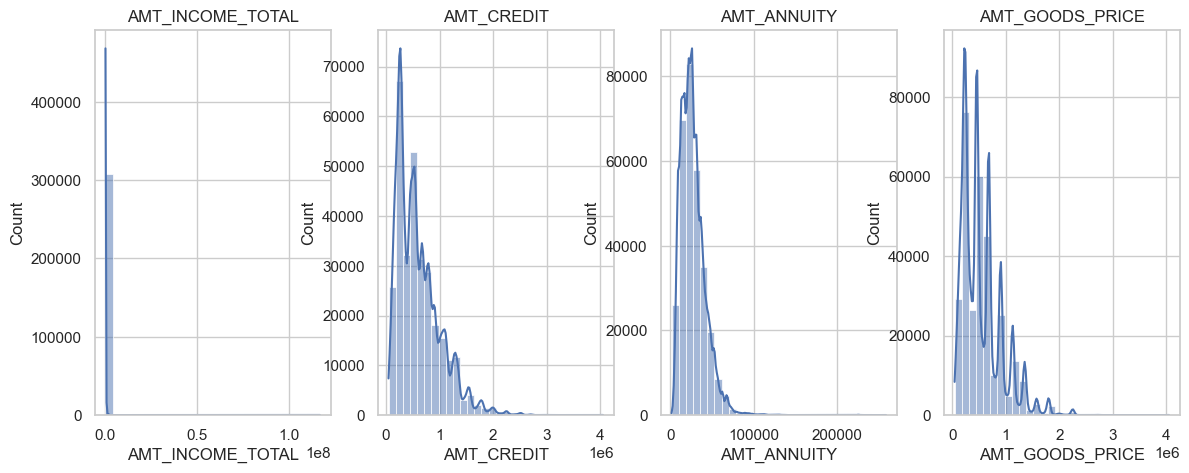

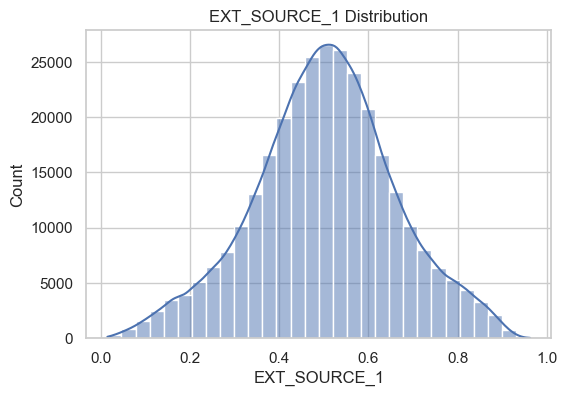

In [7]:
# Histograms for skewed numerical variables

fig, axes = plt.subplots(1, 4, figsize=(14,5))

num_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE"
]

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["EXT_SOURCE_1"].dropna(), bins=30, kde=True)
plt.title("EXT_SOURCE_1 Distribution")
plt.xlabel("EXT_SOURCE_1")
plt.ylabel("Count")
plt.show()

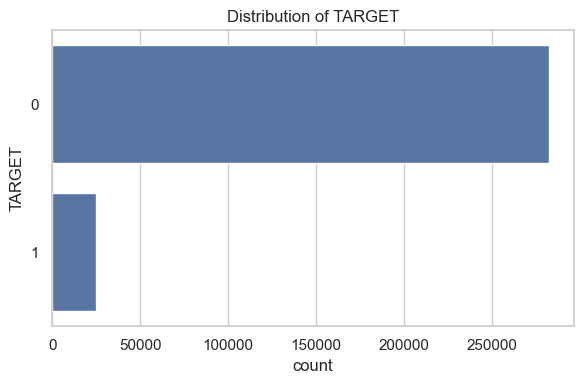

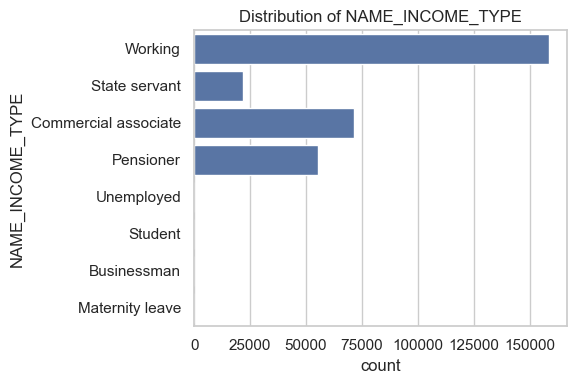

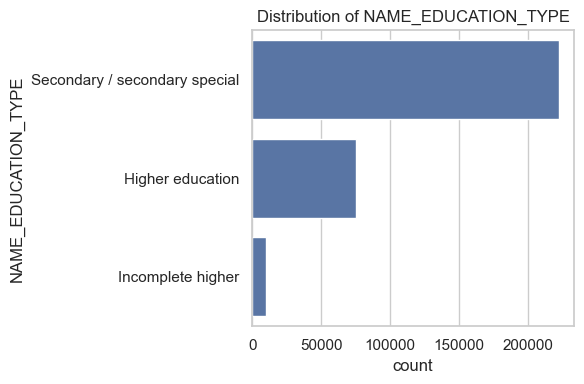

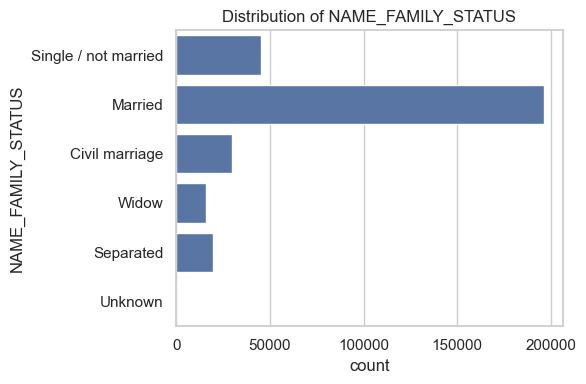

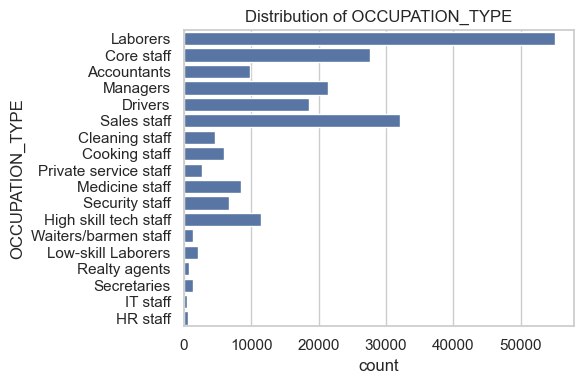

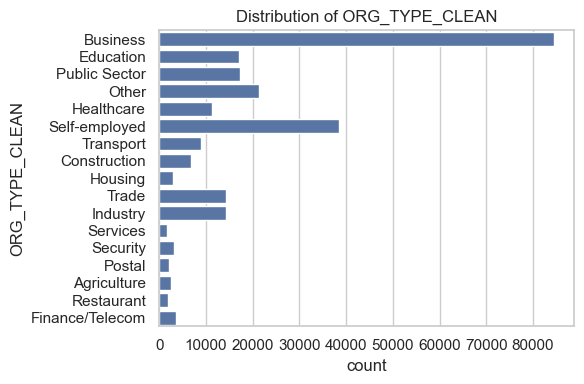

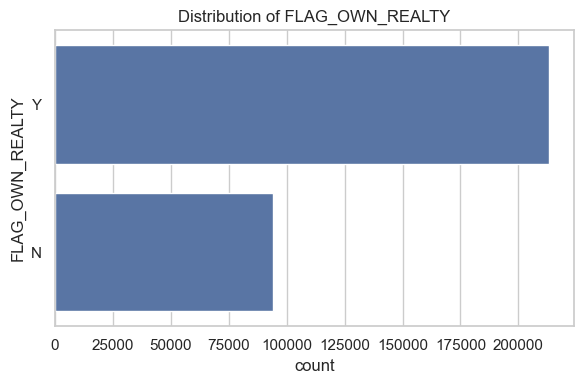

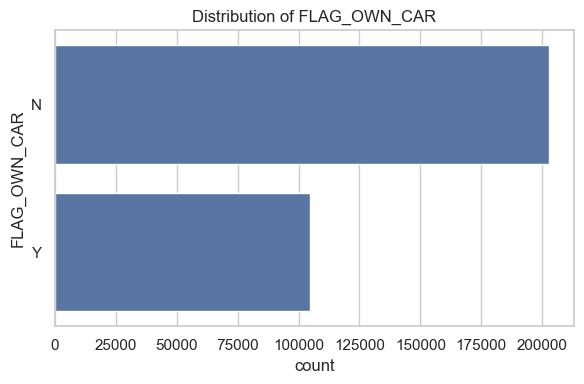

In [23]:
# Important categorical features to visualize with bar plots
barplot_cols = [
    "TARGET",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "OCCUPATION_TYPE",
    "ORG_TYPE_CLEAN",
    "FLAG_OWN_REALTY",
    "FLAG_OWN_CAR"
]

# Plot bar charts
for col in barplot_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

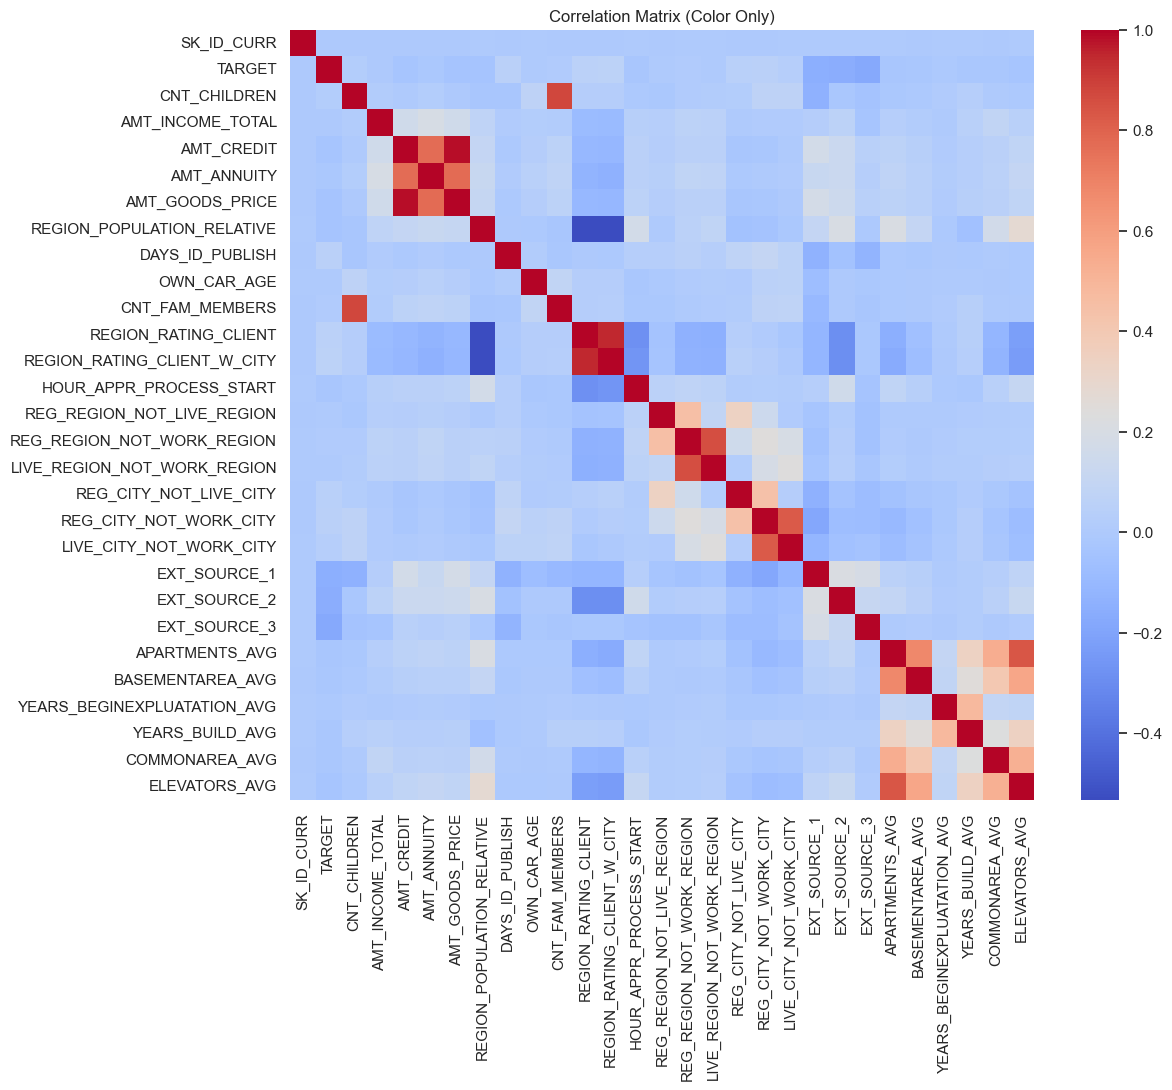

In [27]:
# Correlation Matrix
# Select numerical columns only
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_41,
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Matrix (Color Only)")
plt.show()

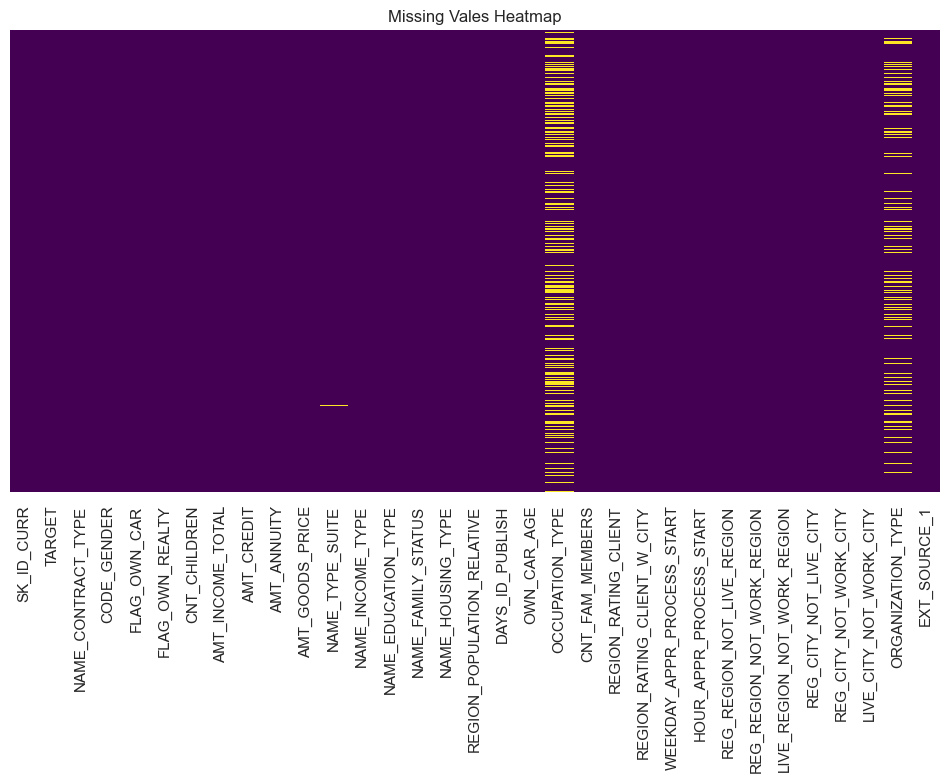

In [10]:
# Handle Missing Values

# Visualize missingness
plt.figure(figsize=(12,6))
sns.heatmap(df.iloc[:, :33].isnull(),cbar=False, yticklabels=False,cmap='viridis')
plt.title("Missing Vales Heatmap")
plt.show()

In [12]:
# KNN Imputation for Numerical Features
from sklearn.impute import KNNImputer

# Select numerical columns (after removing near-zero variance features)
num_cols = df.iloc[:,:41].select_dtypes(include=[np.number]).columns

# Initialize the imputer
imputer = KNNImputer(n_neighbors=5)
df[num_cols] = imputer.fit_transform(df[num_cols])

print("Missing values after KNN imputation (numerical):")
print(df["EXT_SOURCE_1"].isnull().sum())

# For categorical columns, we can impute using the mode (if needed)
cat_cols = df.iloc[:,:41].select_dtypes(include=["object"]).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

Missing values after KNN imputation (numerical):
0


/var/folders/y0/clfwbm7x729d_5b50phhndcw0000gn/T/ipykernel_40490/1350889776.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.iloc[:,:41].select_dtypes(include=["object"]).columns


In [15]:
from sklearn.feature_selection import VarianceThreshold

# # First, let’s check the variance of the numerical features.
num_features = df.iloc[:,:41].select_dtypes(include=[np.number]).columns
variance = df[num_features].var()
print("Variance of numerical features:")
print(variance)
# We choose a threshold. Here, we set a threshold of 0.03.
vt = VarianceThreshold(threshold=0.03)
X_num = df[num_features].fillna(0)  # temporarily fill missing values for variance calculation
vt.fit(X_num)
features_to_keep = X_num.columns[vt.get_support()]

print("\nNumerical features to keep (variance above threshold):")
print(list(features_to_keep))

# Drop near-zero variance features from the dataframe.
features_to_drop = set(num_features) - set(features_to_keep)
print("\nDropping features:", features_to_drop)
df = df.drop(columns=list(features_to_drop))


Variance of numerical features:
SK_ID_CURR                     1.056582e+10
TARGET                         7.421192e-02
CNT_CHILDREN                   5.214593e-01
AMT_INCOME_TOTAL               5.622739e+10
AMT_CREDIT                     1.619988e+11
AMT_ANNUITY                    2.100650e+08
AMT_GOODS_PRICE                1.364624e+11
DAYS_ID_PUBLISH                2.278441e+06
OWN_CAR_AGE                    8.117133e+01
CNT_FAM_MEMBERS                8.293364e-01
REGION_RATING_CLIENT           2.591155e-01
REGION_RATING_CLIENT_W_CITY    2.527445e-01
HOUR_APPR_PROCESS_START        1.066566e+01
REG_REGION_NOT_WORK_REGION     4.819159e-02
LIVE_REGION_NOT_WORK_REGION    3.900570e-02
REG_CITY_NOT_LIVE_CITY         7.206206e-02
REG_CITY_NOT_WORK_CITY         1.773453e-01
LIVE_CITY_NOT_WORK_CITY        1.473152e-01
EXT_SOURCE_2                   3.644468e-02
EXT_SOURCE_3                   3.218565e-02
ENTRANCES_AVG                  1.000983e-02
FLOORSMAX_AVG                  2.092093e-02


In [17]:
# Address Outliers
df.iloc[:,:41].dtypes

SK_ID_CURR                      float64
TARGET                          float64
NAME_CONTRACT_TYPE                  str
CODE_GENDER                         str
FLAG_OWN_CAR                        str
FLAG_OWN_REALTY                     str
CNT_CHILDREN                    float64
AMT_INCOME_TOTAL                float64
AMT_CREDIT                      float64
AMT_ANNUITY                     float64
AMT_GOODS_PRICE                 float64
NAME_TYPE_SUITE                     str
NAME_INCOME_TYPE                    str
NAME_EDUCATION_TYPE                 str
NAME_FAMILY_STATUS                  str
NAME_HOUSING_TYPE                   str
DAYS_ID_PUBLISH                 float64
OWN_CAR_AGE                     float64
OCCUPATION_TYPE                     str
CNT_FAM_MEMBERS                 float64
REGION_RATING_CLIENT            float64
REGION_RATING_CLIENT_W_CITY     float64
WEEKDAY_APPR_PROCESS_START          str
HOUR_APPR_PROCESS_START         float64
REG_REGION_NOT_WORK_REGION      float64


In [18]:
amt_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]
cnt_cols = ["CNT_CHILDREN", "CNT_FAM_MEMBERS"]  # light handling only

# 2) Helper: winsorize / percentile cap
def winsorize_series(s: pd.Series, low_q=0.01, high_q=0.99) -> pd.Series:
    s = pd.to_numeric(s, errors="coerce")
    lo = s.quantile(low_q)
    hi = s.quantile(high_q)
    return s.clip(lower=lo, upper=hi)

# 3) Ensure numeric
for c in amt_cols + cnt_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# 4) Create capped versions (keeps original columns unchanged)
for c in amt_cols:
    if c in df.columns:
        df[c + "_CAP"] = winsorize_series(df[c], low_q=0.01, high_q=0.99)

# Counts: usually OK as-is, but cap extreme tails lightly (e.g., 0.5%–99.5%)
for c in cnt_cols:
    if c in df.columns:
        df[c + "_CAP"] = winsorize_series(df[c], low_q=0.005, high_q=0.995)

# 5) Create log-transformed versions (recommended for skewed AMT_* variables)
# Use log1p to safely handle zeros
for c in amt_cols:
    if c in df.columns:
        df[c + "_LOG"] = np.log1p(df[c])           # log of raw
        df[c + "_CAP_LOG"] = np.log1p(df[c + "_CAP"])  # log of capped

# 6) Quick before/after check (optional)
def outlier_report(s: pd.Series, low_q=0.01, high_q=0.99) -> dict:
    s = pd.to_numeric(s, errors="coerce").dropna()
    lo = s.quantile(low_q)
    hi = s.quantile(high_q)
    return {
        "n": int(s.shape[0]),
        f"p{int(low_q*100)}": float(lo),
        f"p{int(high_q*100)}": float(hi),
        "min": float(s.min()),
        "max": float(s.max()),
        "below_lo": int((s < lo).sum()),
        "above_hi": int((s > hi).sum()),
    }

for c in amt_cols + cnt_cols:
    if c in df.columns:
        print(c, outlier_report(df[c]))

print("\nCreated new columns:")
print([col for col in df.columns if col.endswith(("_CAP", "_LOG", "_CAP_LOG"))])

AMT_INCOME_TOTAL {'n': 307511, 'p1': 45000.0, 'p99': 472500.0, 'min': 25650.0, 'max': 117000000.0, 'below_lo': 1508, 'above_hi': 3014}
AMT_CREDIT {'n': 307511, 'p1': 76410.0, 'p99': 1854000.0, 'min': 45000.0, 'max': 4050000.0, 'below_lo': 2736, 'above_hi': 3075}
AMT_ANNUITY {'n': 307511, 'p1': 6183.0, 'p99': 70006.5, 'min': 1615.5, 'max': 258025.5, 'below_lo': 3075, 'above_hi': 3070}
AMT_GOODS_PRICE {'n': 307511, 'p1': 67500.0, 'p99': 1800000.0, 'min': 40500.0, 'max': 4050000.0, 'below_lo': 2062, 'above_hi': 1431}
CNT_CHILDREN {'n': 307511, 'p1': 0.0, 'p99': 3.0, 'min': 0.0, 'max': 19.0, 'below_lo': 0, 'above_hi': 555}
CNT_FAM_MEMBERS {'n': 307511, 'p1': 1.0, 'p99': 5.0, 'min': 1.0, 'max': 20.0, 'below_lo': 0, 'above_hi': 529}

Created new columns:
['AMT_INCOME_TOTAL_LOG', 'AMT_CREDIT_LOG', 'AMT_ANNUITY_LOG', 'AMT_GOODS_PRICE_LOG', 'AMT_INCOME_TOTAL_CAP', 'AMT_CREDIT_CAP', 'AMT_ANNUITY_CAP', 'AMT_GOODS_PRICE_CAP', 'CNT_CHILDREN_CAP', 'CNT_FAM_MEMBERS_CAP', 'AMT_INCOME_TOTAL_CAP_LOG', '

In [19]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_INCOME_TOTAL_CAP,AMT_CREDIT_CAP,AMT_ANNUITY_CAP,AMT_GOODS_PRICE_CAP,CNT_CHILDREN_CAP,CNT_FAM_MEMBERS_CAP,AMT_INCOME_TOTAL_CAP_LOG,AMT_CREDIT_CAP_LOG,AMT_ANNUITY_CAP_LOG,AMT_GOODS_PRICE_CAP_LOG
0,100002.0,1.0,Cash loans,M,N,Y,0.0,202500.0,406597.5,24700.5,...,202500.0,406597.5,24700.5,351000.0,0.0,1.0,12.218500,12.915581,10.114619,12.768544
1,100003.0,0.0,Cash loans,F,N,N,0.0,270000.0,1293502.5,35698.5,...,270000.0,1293502.5,35698.5,1129500.0,0.0,2.0,12.506181,14.072865,10.482892,13.937287
2,100004.0,0.0,Revolving loans,M,Y,Y,0.0,67500.0,135000.0,6750.0,...,67500.0,135000.0,6750.0,135000.0,0.0,1.0,11.119898,11.813037,8.817446,11.813037
3,100006.0,0.0,Cash loans,F,N,Y,0.0,135000.0,312682.5,29686.5,...,135000.0,312682.5,29686.5,297000.0,0.0,2.0,11.813037,12.652947,10.298481,12.601491
4,100007.0,0.0,Cash loans,M,N,Y,0.0,121500.0,513000.0,21865.5,...,121500.0,513000.0,21865.5,513000.0,0.0,1.0,11.707678,13.148033,9.992711,13.148033
